<a href="https://colab.research.google.com/github/maryemmahmmoudd/projects/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data_copy=data.copy()

In [6]:
print("Missing values:")
data_copy.isnull().sum()

Missing values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
data_copy["TotalCharges"] = pd.to_numeric(
    data_copy["TotalCharges"],
    errors="coerce"
)

In [8]:
data_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
data_copy[data_copy["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
data_copy = data_copy.dropna(subset=["TotalCharges"])

In [11]:
print("Dataset shape:", data_copy.shape)


Dataset shape: (7032, 21)


In [12]:
print("Duplicate customer IDs:", data_copy["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [13]:
churn_counts = data_copy["Churn"].value_counts()
print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [14]:
churn_percentage = data_copy["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


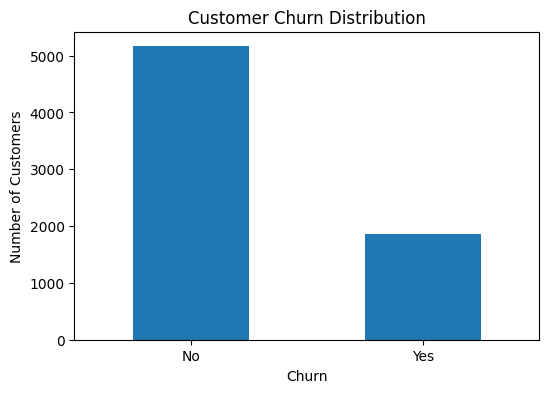

In [15]:
churn_counts = data_copy["Churn"].value_counts()

plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

""imbalance data""


In [16]:
data_copy.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


<Figure size 600x400 with 0 Axes>

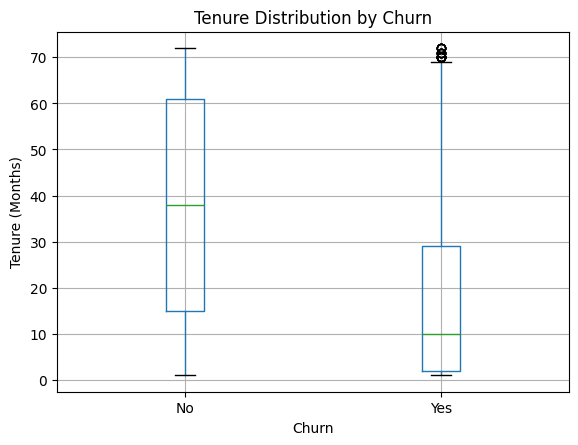

In [17]:
plt.figure(figsize=(6, 4))

data_copy.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [18]:
contract_churn = pd.crosstab(
    data_copy["Contract"],
    data_copy["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


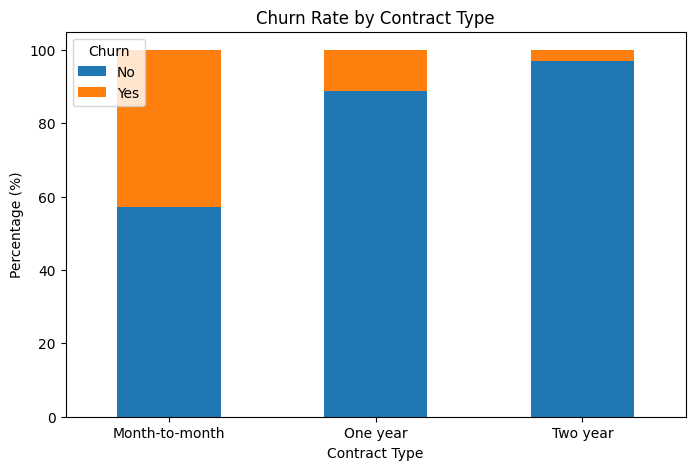

In [19]:
contract_churn = pd.crosstab(
    data_copy["Contract"],
    data_copy["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [20]:
data_copy.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


<Figure size 600x400 with 0 Axes>

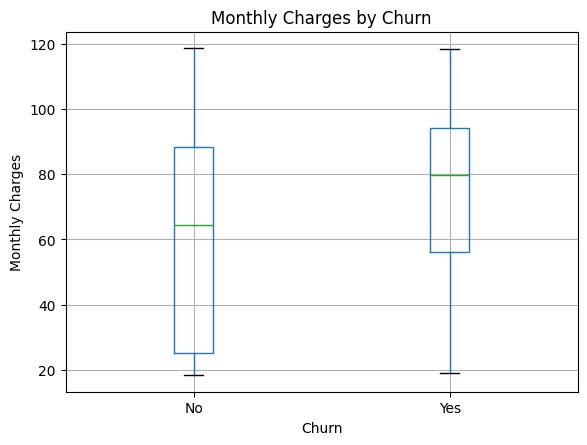

In [21]:
plt.figure(figsize=(6, 4))

data_copy.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Contract: نسبة الـ Churn أعلى بوضوح بين عملاء Month-to-month.

Monthly Charges: متوسط الـ MonthlyCharges أعلى بين العملاء اللي عملوا Churn.

Tenure: العملاء اللي عملوا Churn عندهم متوسط tenure أقل:

In [22]:
internet_churn = pd.crosstab(
    data_copy["InternetService"],
    data_copy["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


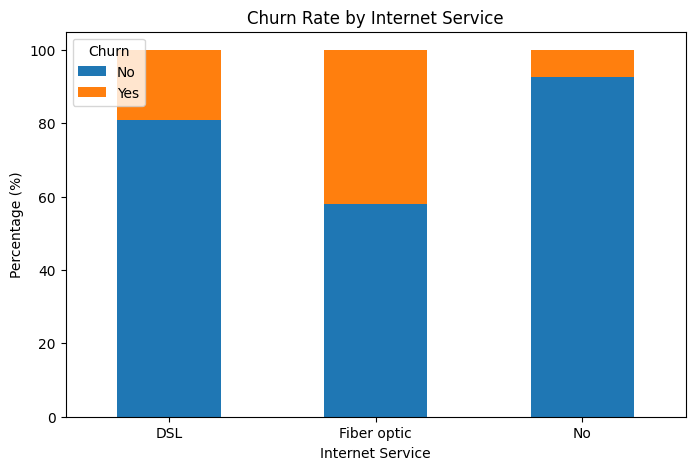

In [23]:
internet_churn = pd.crosstab(
    data_copy["InternetService"],
    data_copy["Churn"],
    normalize="index"
) * 100

internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [24]:
payment_churn = pd.crosstab(
    data_copy["PaymentMethod"],
    data_copy["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


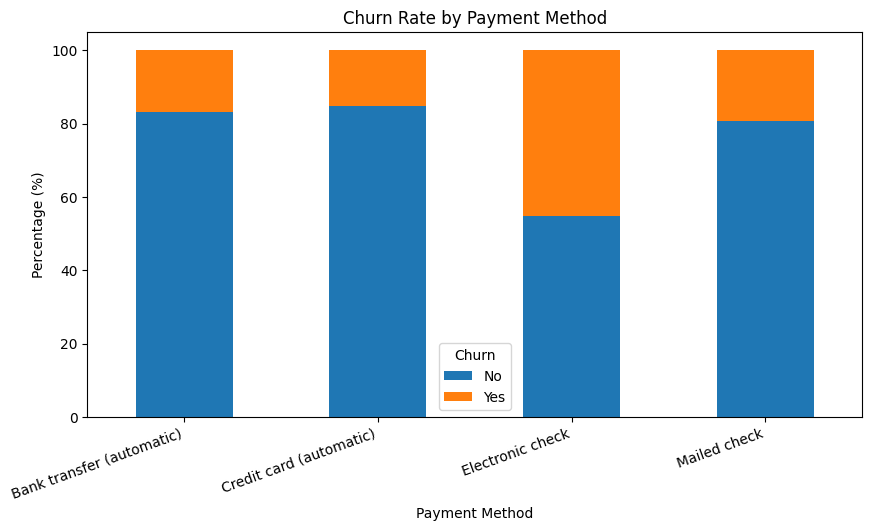

In [25]:
payment_churn = pd.crosstab(
    data_copy["PaymentMethod"],
    data_copy["Churn"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")

plt.show()

In [26]:
techsupport_churn = pd.crosstab(
    data_copy["TechSupport"],
    data_copy["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


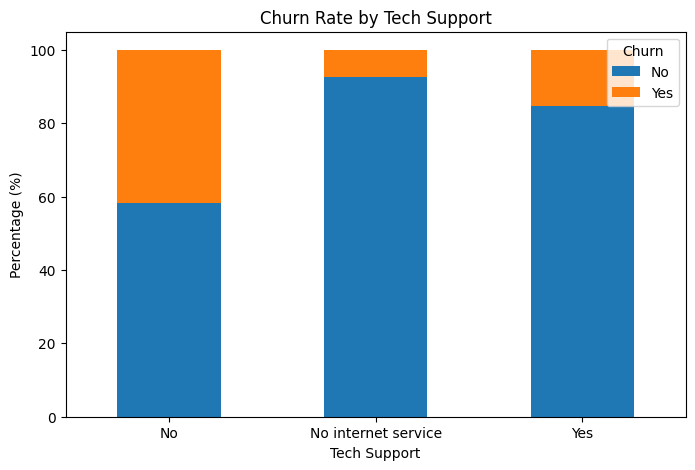

In [27]:
techsupport_churn = pd.crosstab(
    data_copy["TechSupport"],
    data_copy["Churn"],
    normalize="index"
) * 100

techsupport_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Fiber optic customers have a substantially higher observed churn rate

Customers with technical support show a lower observed churn rate

In [28]:
senior_churn = pd.crosstab(
    data_copy["SeniorCitizen"],
    data_copy["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


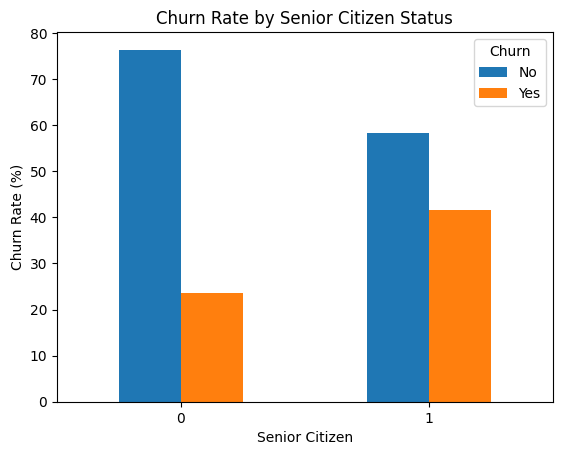

In [29]:
senior_churn.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [31]:
partner_churn = pd.crosstab(
    data_copy["Partner"],
    data_copy["Churn"],
    normalize="index"
) * 100
partner_churn


Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


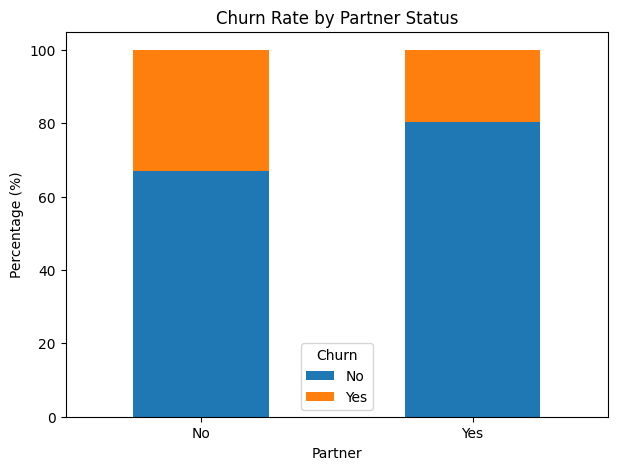

In [32]:
partner_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()



In [33]:
device_churn = pd.crosstab(
    data_copy["DeviceProtection"],
    data_copy["Churn"],
    normalize="index"
) * 100
device_churn

Churn,No,Yes
DeviceProtection,,
No,60.859729,39.140271
No internet service,92.565789,7.434211
Yes,77.460711,22.539289


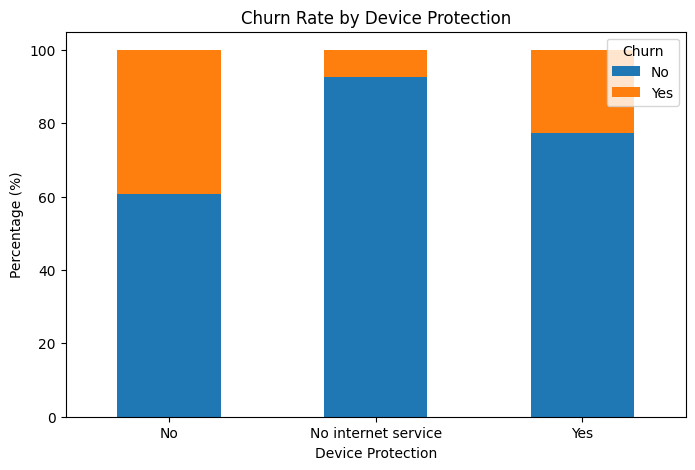

In [34]:
device_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [35]:
data_copy["TenureGroup"] = pd.cut(
    data_copy["tenure"],
    bins=[0, 12, 24, 48, float("inf")],
    labels=["0-12 months", "13-24 months", "25-48 months", "49+ months"]
)

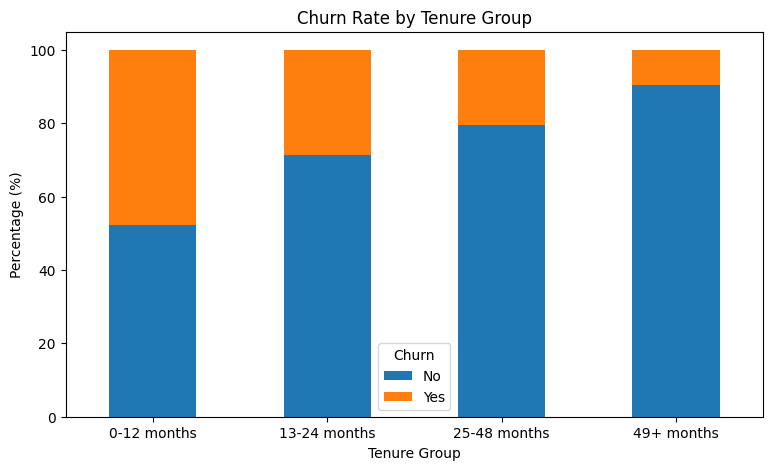

In [36]:
tenure_churn = pd.crosstab(
    data_copy["TenureGroup"],
    data_copy["Churn"],
    normalize="index"
) * 100

tenure_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [40]:
data_copy["MonthlyChargeGroup"] = pd.cut(
    data_copy["MonthlyCharges"],
    bins=[0, 30, 60, 90, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

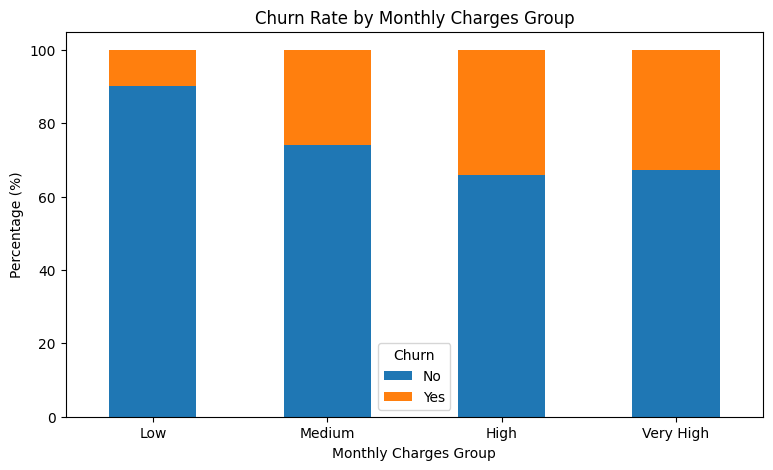

In [41]:
charge_churn = pd.crosstab(
    data_copy["MonthlyChargeGroup"],
    data_copy["Churn"],
    normalize="index"
) * 100

charge_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Churn Rate by Monthly Charges Group")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [37]:
numeric_data = data_copy[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
]

correlation = numeric_data.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


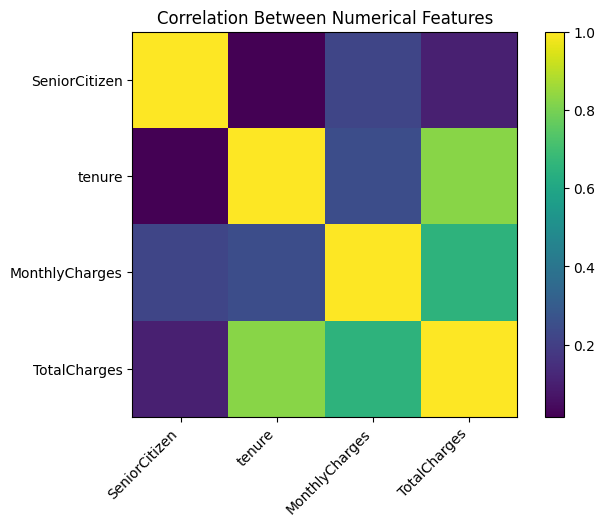

In [38]:
plt.figure(figsize=(7, 5))

plt.imshow(correlation)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar()

plt.title("Correlation Between Numerical Features")

plt.show()

In [42]:
features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "Partner",
    "Dependents",
    "SeniorCitizen",
    "TenureGroup",
    "MonthlyChargeGroup"
]

for col in features:
    print(f"\n--- {col} ---")

    churn_rate = pd.crosstab(
        data_copy[col],
        data_copy["Churn"],
        normalize="index"
    ) * 100

    print(churn_rate.round(2))


--- Contract ---
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85

--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43

--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20

--- TechSupport ---
Churn                   No    Yes
TechSupport                      
No                   58.35  41.65
No internet service  92.57   7.43
Yes                  84.80  15.20

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.22  41.78
No internet service  92.57   7.43
Yes                  85.36  14.64

--- OnlineBac

In [43]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customerID          7032 non-null   object  
 1   gender              7032 non-null   object  
 2   SeniorCitizen       7032 non-null   int64   
 3   Partner             7032 non-null   object  
 4   Dependents          7032 non-null   object  
 5   tenure              7032 non-null   int64   
 6   PhoneService        7032 non-null   object  
 7   MultipleLines       7032 non-null   object  
 8   InternetService     7032 non-null   object  
 9   OnlineSecurity      7032 non-null   object  
 10  OnlineBackup        7032 non-null   object  
 11  DeviceProtection    7032 non-null   object  
 12  TechSupport         7032 non-null   object  
 13  StreamingTV         7032 non-null   object  
 14  StreamingMovies     7032 non-null   object  
 15  Contract            7032 non-null   object 

"DATA PREPROCESSING

In [44]:
ml_data = data_copy.drop(
    columns=["customerID", "TenureGroup", "MonthlyChargeGroup"]
)

ml_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
X = ml_data.drop(columns=["Churn"])
y = ml_data["Churn"]

In [46]:
X.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


In [49]:
print("Train distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train distribution:
Churn
No     73.422222
Yes    26.577778
Name: proportion, dtype: float64

Test distribution:
Churn
No     73.418621
Yes    26.581379
Name: proportion, dtype: float64


In [50]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [51]:
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [53]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [56]:
print("Before encoding:", X_train.shape)
print("After encoding:", X_train_processed.shape)

Before encoding: (5625, 19)
After encoding: (5625, 45)


In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [58]:
y_pred = model.predict(X_test_processed)

In [59]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



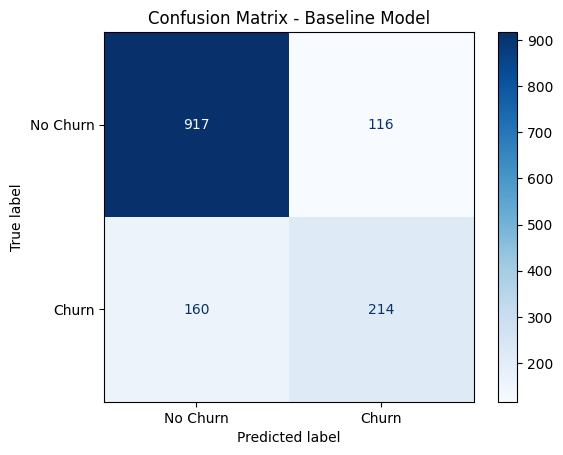

In [60]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Baseline Model")
plt.show()

In [61]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [62]:
balanced_model.fit(X_train_processed, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [63]:
y_pred_balanced = balanced_model.predict(X_test_processed)

In [64]:
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7256574271499645
              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



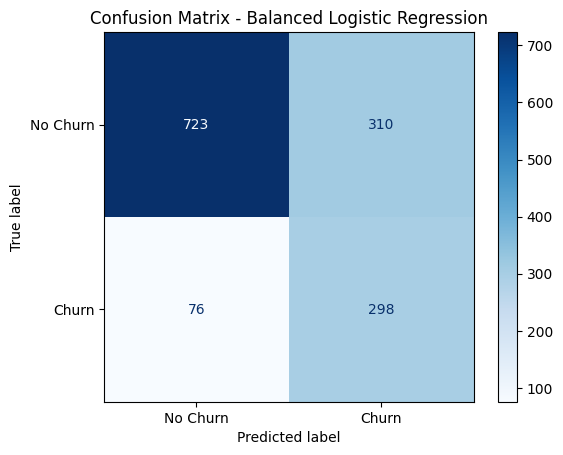

[[723 310]
 [ 76 298]]


In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_balanced,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

print(cm)

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)



In [67]:

rf_model.fit(X_train_processed, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [68]:
y_pred_rf = rf_model.predict(X_test_processed)

In [69]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7839374555792467

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1033
         Yes       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [70]:
feature_names = preprocessor.get_feature_names_out()

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})


In [71]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                                Feature  Importance
3                     num__TotalCharges    0.141613
1                           num__tenure    0.130659
2                   num__MonthlyCharges    0.122796
36         cat__Contract_Month-to-month    0.073600
38               cat__Contract_Two year    0.037696
18               cat__OnlineSecurity_No    0.037482
27                  cat__TechSupport_No    0.032245
43  cat__PaymentMethod_Electronic check    0.028836
16     cat__InternetService_Fiber optic    0.027259
21                 cat__OnlineBackup_No    0.017718
4                    cat__gender_Female    0.016419
0                    num__SeniorCitizen    0.016347
5                      cat__gender_Male    0.016123
40            cat__PaperlessBilling_Yes    0.014658
39             cat__PaperlessBilling_No    0.014165


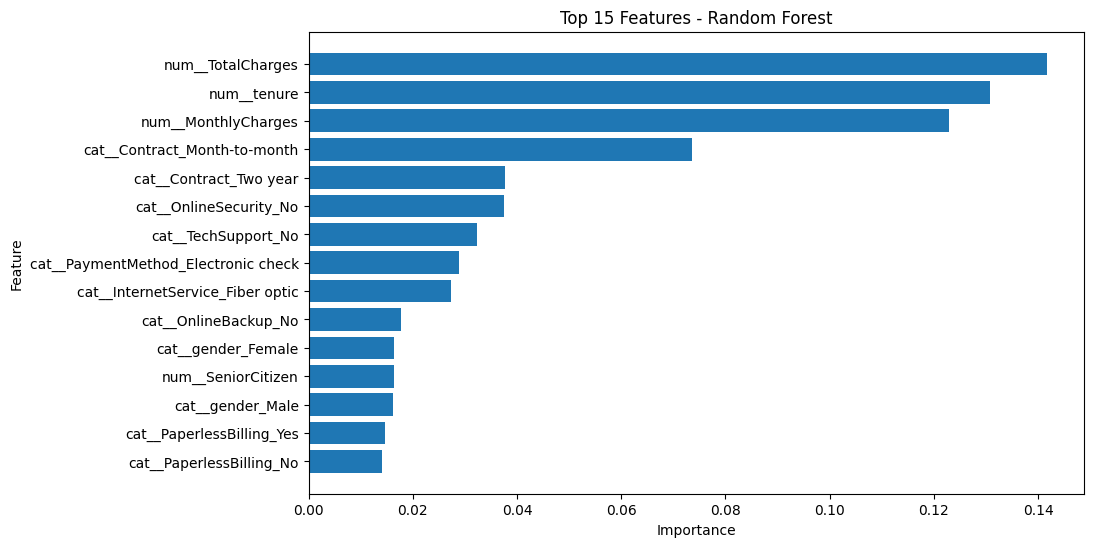

In [72]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.show()

In [73]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get churn probabilities
y_prob = balanced_model.predict_proba(X_test_processed)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    y_pred_threshold = pd.Series(y_pred_threshold).map({
        0: "No",
        1: "Yes"
    })

    precision = precision_score(y_test, y_pred_threshold, pos_label="Yes")
    recall = recall_score(y_test, y_pred_threshold, pos_label="Yes")
    f1 = f1_score(y_test, y_pred_threshold, pos_label="Yes")

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.41
Recall: 0.93
F1-score: 0.57
------------------------------
Threshold: 0.4
Precision: 0.45
Recall: 0.87
F1-score: 0.60
------------------------------
Threshold: 0.5
Precision: 0.49
Recall: 0.80
F1-score: 0.61
------------------------------
Threshold: 0.6
Precision: 0.54
Recall: 0.72
F1-score: 0.62
------------------------------
Threshold: 0.7
Precision: 0.61
Recall: 0.62
F1-score: 0.61
------------------------------


In [74]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_processed, y_train)


GradientBoostingClassifier(random_state=42)

In [75]:
y_pred_gb = gb_model.predict(X_test_processed)

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.7960199004975125

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.87      1033
         Yes       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [77]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

cv_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

cv_results = cross_validate(
    cv_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring=scoring
)

print("Mean Accuracy:", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1:", cv_results["test_f1"].mean())

Mean Accuracy: 0.8023111111111112
Mean Precision: 0.7494362205853523
Mean Recall: 0.7209151570610672
Mean F1: 0.7323278388455698


In [78]:
balanced_cv_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

cv_results_balanced = cross_validate(
    balanced_cv_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring=scoring
)

print("Mean Accuracy:", cv_results_balanced["test_accuracy"].mean())
print("Mean Precision:", cv_results_balanced["test_precision"].mean())
print("Mean Recall:", cv_results_balanced["test_recall"].mean())
print("Mean F1:", cv_results_balanced["test_f1"].mean())

Mean Accuracy: 0.7521777777777778
Mean Precision: 0.7169110429713097
Mean Recall: 0.7687137107549782
Mean F1: 0.7228571942512445


In [79]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.8038,
        0.7257,
        0.7839,
        0.7960
    ],
    "Churn Precision": [
        0.65,
        0.49,
        0.62,
        0.64
    ],
    "Churn Recall": [
        0.57,
        0.80,
        0.47,
        0.53
    ],
    "Churn F1": [
        0.61,
        0.61,
        0.54,
        0.58
    ]
})

model_results


,Model,Accuracy,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.8038,0.65,0.57,0.61
1,Balanced Logistic Regression,0.7257,0.49,0.80,0.61
2,Random Forest,0.7839,0.62,0.47,0.54
3,Gradient Boosting,0.7960,0.64,0.53,0.58


In [80]:
model_results.sort_values(
    by="Churn F1",
    ascending=False
)

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.8038,0.65,0.57,0.61
1,Balanced Logistic Regression,0.7257,0.49,0.80,0.61
3,Gradient Boosting,0.7960,0.64,0.53,0.58
2,Random Forest,0.7839,0.62,0.47,0.54


**Among the evaluated models, Logistic Regression achieved the highest test accuracy and tied for the highest churn F1-score, while the balanced version provided substantially higher churn recall**

In [81]:
X_all_processed = preprocessor.transform(X)

churn_probability = balanced_model.predict_proba(X_all_processed)[:, 1]

customer_risk = X.copy()

customer_risk["Churn_Probability"] = churn_probability

In [82]:
customer_risk["Risk_Segment"] = pd.cut(
    customer_risk["Churn_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

customer_risk[[
    "tenure",
    "MonthlyCharges",
    "Contract",
    "InternetService",
    "Churn_Probability",
    "Risk_Segment"
]].head()

,tenure,MonthlyCharges,Contract,InternetService,Churn_Probability,Risk_Segment
0,1,29.85,Month-to-month,DSL,0.809656,High Risk
1,34,56.95,One year,DSL,0.116409,Low Risk
2,2,53.85,Month-to-month,DSL,0.515596,Medium Risk
3,45,42.30,One year,DSL,0.081040,Low Risk
4,2,70.70,Month-to-month,Fiber optic,0.852570,High Risk


In [83]:
risk_distribution = customer_risk["Risk_Segment"].value_counts()

print(risk_distribution)

Risk_Segment
Low Risk       2962
High Risk      2394
Medium Risk    1676
Name: count, dtype: int64


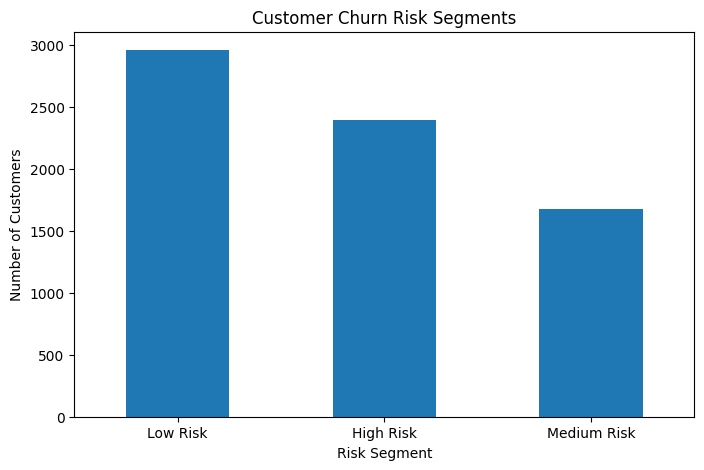

In [84]:
risk_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Risk Segments")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [87]:
customer_risk["Actual_Churn"] = y.values

In [88]:
risk_churn_rate = (
    customer_risk
    .groupby("Risk_Segment", observed=True)["Actual_Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(risk_churn_rate)


Risk_Segment
Low Risk        4.456448
Medium Risk    23.269690
High Risk      56.265664
Name: Actual_Churn, dtype: float64


In [89]:
risk_profile = customer_risk.groupby(
    "Risk_Segment",
    observed=True
).agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "TotalCharges": "mean"
})

print(risk_profile)

                 tenure  MonthlyCharges  TotalCharges
Risk_Segment                                         
Low Risk      49.630317       55.927178   3095.011327
Medium Risk   26.967780       62.035203   2224.335949
High Risk     14.948622       77.708312   1320.283250


In [90]:
for column in [
    "Contract",
    "InternetService",
    "TechSupport",
    "OnlineSecurity",
    "PaymentMethod"
]:
    print("\n", column)
    print(
        pd.crosstab(
            customer_risk["Risk_Segment"],
            customer_risk[column],
            normalize="index"
        ).round(3) * 100
    )



 Contract
Contract      Month-to-month  One year  Two year
Risk_Segment                                    
Low Risk                 9.9      34.0      56.1
Medium Risk             73.1      25.6       1.3
High Risk               98.5       1.5       0.0

 InternetService
InternetService   DSL  Fiber optic    No
Risk_Segment                            
Low Risk         42.1         19.8  38.2
Medium Risk      38.2         38.7  23.1
High Risk        22.1         77.8   0.1

 TechSupport
TechSupport     No  No internet service   Yes
Risk_Segment                                 
Low Risk      18.4                 38.2  43.4
Medium Risk   49.8                 23.1  27.1
High Risk     87.4                  0.1  12.5

 OnlineSecurity
OnlineSecurity    No  No internet service   Yes
Risk_Segment                                   
Low Risk        19.1                 38.2  42.7
Medium Risk     47.5                 23.1  29.4
High Risk       89.2                  0.1  10.7

 PaymentMethod
Paym

In [91]:
powerbi_data = data_copy.drop(
    columns=["TenureGroup", "MonthlyChargeGroup"]
).copy()

powerbi_data["Churn_Probability"] = churn_probability

powerbi_data["Risk_Segment"] = pd.cut(
    powerbi_data["Churn_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

powerbi_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Probability,Risk_Segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0.809656,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0.116409,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0.515596,Medium Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0.081040,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0.852570,High Risk


In [92]:
print(powerbi_data.shape)
print(powerbi_data.isnull().sum().sum())
print(powerbi_data["Risk_Segment"].value_counts())

(7032, 23)
0
Risk_Segment
Low Risk       2962
High Risk      2394
Medium Risk    1676
Name: count, dtype: int64


In [93]:
powerbi_data.to_csv(
    "/content/telco_churn_powerbi.csv",
    index=False
)

In [94]:
from google.colab import files

files.download("/content/telco_churn_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>